In [203]:
import pandas as pd
import krippendorff
from irrCAC.raw import CAC
import seaborn as sns

### Consistency Post Processing

In [204]:
SAMPLE_SIZE = 40
df = pd.read_csv(f'../data/consistency_grades_{SAMPLE_SIZE}_sample.csv')
df = df.drop(columns=['Unnamed: 0'])
df['predictions_0'] = pd.Categorical(df['predictions_0'], ['F', 'D-', 'D', 'D+', 'C-', 'C', 'C+', 'B-', 'B', 'B+', 'A-', 'A', 'A+', 'A++'], ordered=True)
df['predictions_1'] = pd.Categorical(df['predictions_1'], ['F', 'D-', 'D', 'D+', 'C-', 'C', 'C+', 'B-', 'B', 'B+', 'A-', 'A', 'A+', 'A++'], ordered=True)
df['predictions_2'] = pd.Categorical(df['predictions_2'], ['F', 'D-', 'D', 'D+', 'C-', 'C', 'C+', 'B-', 'B', 'B+', 'A-', 'A', 'A+', 'A++'], ordered=True)
df['predictions_3'] = pd.Categorical(df['predictions_3'], ['F', 'D-', 'D', 'D+', 'C-', 'C', 'C+', 'B-', 'B', 'B+', 'A-', 'A', 'A+', 'A++'], ordered=True)
df.head()

,assignment_number,query,func_code_string,text,predictions_0,predictions_1,predictions_2,predictions_3
0,461,This method changes the day for example morning to night,public void changeDay(){\n // change the day\n isDay=!isDay;\n },This method changes the day for example morning to night<CODESPLIT>public void changeDay(){\n // change the day\n isDay=!isDay;\n },D-,D-,D-,D-
1,461,This method sets the day to false to indicate that it is night,public void setfalse(){\n // set day to night\n isDay = false;\n },This method sets the day to false to indicate that it is night<CODESPLIT>public void setfalse(){\n // set day to night\n isDay = false;\n },B-,B-,B-,B-
2,461,This method returns a boolean value to indicate if it is morning or\nnight\n\n@return Boolean value to indicate if it is morning or night,public boolean getDay(){\n return isDay;\n },This method returns a boolean value to indicate if it is morning or\nnight\n\n@return Boolean value to indicate if it is morning or night<CODESPLIT>public boolean getDay(){\n return isDay;\n },F,F,F,F
3,461,This method returns a random integer value\n\n@param Integer number to be the max limit of the random number generator\n\n@return Integer number of the random number generated.,public int getRandom(int number){\n // return a random number from 0 to a number in the parameter\n return rand.nextInt(number); \n },This method returns a random integer value\n\n@param Integer number to be the max limit of the random number generator\n\n@return Integer number of the random number generated.<CODESPLIT>public int getRandom(int number){\n // return a random number from 0 to a number in the parameter\n return rand.nextInt(number); \n },D-,D-,D-,D-
4,461,This method increments the time used for the countdown of the day,public void incrementTime()\n {\n // increment the time by 1\n time++;\n },This method increments the time used for the countdown of the day<CODESPLIT>public void incrementTime()\n {\n // increment the time by 1\n time++;\n },D-,D-,D-,D-


In [205]:
df['assignment_number'].unique().shape

(40,)

#### Consistency Calculation per code doc/code pair

In [206]:
def irr_results(df):
    k_df = df[['predictions_0', 'predictions_1', 'predictions_2', 'predictions_3']].copy()
    k_df = k_df.dropna()
    k_df['predictions_0'] = k_df['predictions_0'].cat.codes
    k_df['predictions_1'] = k_df['predictions_1'].cat.codes
    k_df['predictions_2'] = k_df['predictions_2'].cat.codes
    k_df['predictions_3'] = k_df['predictions_3'].cat.codes
    k_df = k_df.transpose()

    cac = CAC(k_df.T, 'ordinal')
    ac2 = cac.gwet()['est']['coefficient_value']

    alpha = krippendorff.alpha(k_df.to_numpy(), level_of_measurement='ordinal')

    return f'Krippendorfs Alpha: {alpha}, Gwet Coefficient: {ac2} for SAMPLE size {SAMPLE_SIZE}'

irr_results(df)


'Krippendorfs Alpha: 1.0, Gwet Coefficient: 1.0 for SAMPLE size 40'

In [207]:
df[(df['predictions_0'] != df['predictions_1']) & (df['predictions_1'] != df['predictions_2']) & (df['predictions_2'] != df['predictions_3'])].dropna()

,assignment_number,query,func_code_string,text,predictions_0,predictions_1,predictions_2,predictions_3


### Project-Level

In [208]:
def consensus(group):
    consensus_dict = {}
    for grade in group:
        if grade not in consensus_dict:
            consensus_dict[grade] = 1
        else:
            consensus_dict[grade] += 1
    return max(consensus_dict, key=consensus_dict.get)

project_df = df.copy()
project_df = project_df.dropna()
project_df = project_df[['assignment_number', 'predictions_0', 'predictions_1', 'predictions_2', 'predictions_3']].groupby('assignment_number').agg(consensus)
project_df.head()

,predictions_0,predictions_1,predictions_2,predictions_3
assignment_number,,,,
5,D-,D-,D-,D-
23,D-,D-,D-,D-
25,D-,D-,D-,D-
53,D-,D-,D-,D-
84,D-,D-,D-,D-


In [209]:
irr_results(project_df)

'Krippendorfs Alpha: 1.0, Gwet Coefficient: 1.0 for SAMPLE size 40'

In [210]:
project_df[(project_df['predictions_0'] != project_df['predictions_1']) & (project_df['predictions_1'] != project_df['predictions_2']) & (project_df['predictions_2'] != project_df['predictions_3'])]

,predictions_0,predictions_1,predictions_2,predictions_3
assignment_number,,,,


### Plots

In [211]:
grey = (187/255, 187/255, 187/255)
darkgreen = (51/255, 117/255, 56/255)
teal = (93/255, 168/255, 153/255)
blue = (148/255, 203/255, 236/255)
yellow = (220/255, 205/255, 125/255)
red = (168/255, 96/255, 93/255)
pale_yellow = (164/255, 168/255, 93/255)
sns.set_theme(style="whitegrid")

#### Ungraded Pairs

In [212]:
ungraded_df = df.copy()
ungraded_df['Graded'] = ungraded_df['predictions_0'].apply(lambda x: 'Ungraded' if x is None else 'Graded')
ungraded_df['Graded'] = ungraded_df['Graded'].fillna('Ungraded')
ungraded_df

,assignment_number,query,func_code_string,text,predictions_0,predictions_1,predictions_2,predictions_3,Graded
0,461,This method changes the day for example morning to night,public void changeDay(){\n // change the day\n isDay=!isDay;\n },This method changes the day for example morning to night<CODESPLIT>public void changeDay(){\n // change the day\n isDay=!isDay;\n },D-,D-,D-,D-,Graded
1,461,This method sets the day to false to indicate that it is night,public void setfalse(){\n // set day to night\n isDay = false;\n },This method sets the day to false to indicate that it is night<CODESPLIT>public void setfalse(){\n // set day to night\n isDay = false;\n },B-,B-,B-,B-,Graded
2,461,This method returns a boolean value to indicate if it is morning or\nnight\n\n@return Boolean value to indicate if it is morning or night,public boolean getDay(){\n return isDay;\n },This method returns a boolean value to indicate if it is morning or\nnight\n\n@return Boolean value to indicate if it is morning or night<CODESPLIT>public boolean getDay(){\n return isDay;\n },F,F,F,F,Graded
3,461,This method returns a random integer value\n\n@param Integer number to be the max limit of the random number generator\n\n@return Integer number of the random number generated.,public int getRandom(int number){\n // return a random number from 0 to a number in the parameter\n return rand.nextInt(number); \n },This method returns a random integer value\n\n@param Integer number to be the max limit of the random number generator\n\n@return Integer number of the random number generated.<CODESPLIT>public int getRandom(int number){\n // return a random number from 0 to a number in the parameter\n return rand.nextInt(number); \n },D-,D-,D-,D-,Graded
4,461,This method increments the time used for the countdown of the day,public void incrementTime()\n {\n // increment the time by 1\n time++;\n },This method increments the time used for the countdown of the day<CODESPLIT>public void incrementTime()\n {\n // increment the time by 1\n time++;\n },D-,D-,D-,D-,Graded
...,...,...,...,...,...,...,...,...,...
4804,53,A Lion can breed if it has reached the breeding age and there is a mate nearby.,"private boolean canBreed()\n {\n Field field = getField();\n if (field.mateAdjacent(getLocation(), this) && age >= BREEDING_AGE){\n return true;\n }\n return false; \n }","A Lion can breed if it has reached the breeding age and there is a mate nearby.<CODESPLIT>private boolean canBreed()\n {\n Field field = getField();\n if (field.mateAdjacent(getLocation(), this) && age >= BREEDING_AGE){\n return true;\n }\n return false; \n }",D-,D-,D-,D-,Graded
4805,53,Makes this animal ill. Reduces lifespan by 1000 steps. (Which will kill the animal),protected void setIll(){\n age+=1000;\n },Makes this animal ill. Reduces lifespan by 1000 steps. (Which will kill the animal)<CODESPLIT>protected void setIll(){\n age+=1000;\n },D-,D-,D-,D-,Graded
4806,53,Randomly sets the gender of the animal.,protected void setGender(){\n Random rand = new Random();\n isMale = rand.nextBoolean();\n },Randomly sets the gender of the animal.<CODESPLIT>protected void setGender(){\n Random rand = new Random();\n isMale = rand.nextBoolean();\n },D-,D-,D-,D-,Graded
4807,53,Returns boolean value of whether animal is a male.\n@return boolean checks if the animal is a male.,protected boolean isMale(){\n return isMale;\n },Returns boolean value of whether animal is a male.\n@return boolean checks if the animal is a male.<CODESPLIT>protected boolean isMale(){\n return isMale;\n },D-,D-,D-,D-,Graded


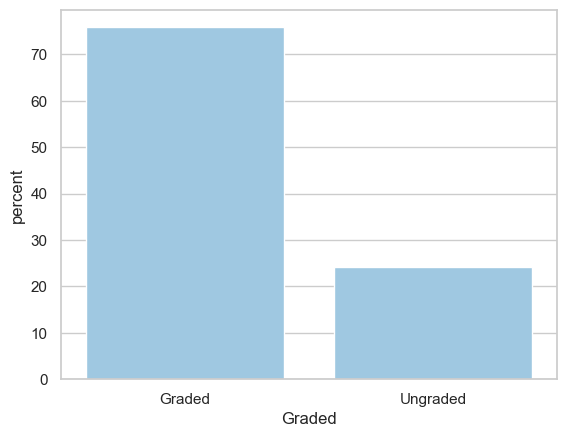

In [213]:
g = sns.countplot(ungraded_df, x='Graded', stat='percent', color=blue)
g.get_figure().savefig(f'plots/ungraded_counts_{SAMPLE_SIZE}.pdf', bbox_inches='tight')

In [214]:
ungraded_df[ungraded_df['Graded'] == 'Ungraded']['text'].apply(lambda x: len(x)).min()
# Max token length of CodeBERT is 512

512

### Project Grade Plot

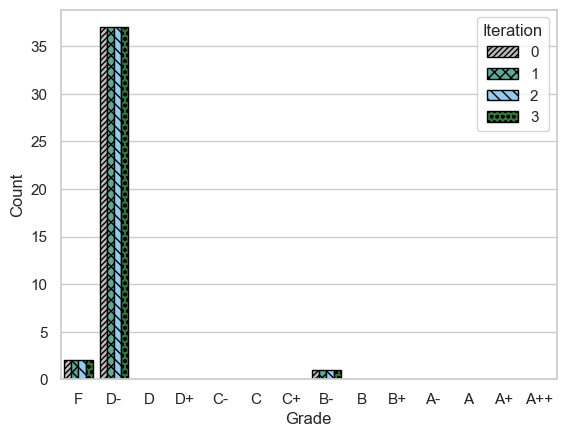

In [216]:
project_plot_df = project_df.copy().reset_index()
project_plot_df.columns = [col[-1] if 'predictions' in col else col for col in project_plot_df.columns]
project_plot_df = project_plot_df.melt(id_vars=['assignment_number'], var_name='predictions_i', value_name='grade')


g = sns.countplot(project_plot_df, x='grade', hue='predictions_i', palette=sns.color_palette([blue, darkgreen, teal, blue]))

hatches = ['//', 'x', '\\', 'o']
colors = [grey, teal, blue, darkgreen]
styles = zip(hatches, colors)


for style, these_bars in zip(styles, g.containers):
    for this_bar in these_bars:
        this_bar.set_hatch(3 * style[0])
        this_bar.set_facecolor(style[1])
        this_bar.set_edgecolor('black')

g.set(xlabel='Grade', ylabel='Count')
handles = g.get_legend_handles_labels()[0]

for i in range(len(handles)):
    handles[i].set_facecolor(colors[i])
    handles[i].set_hatch(3 * hatches[i])
    handles[i].set_edgecolor('black')


g.legend(title='Iteration')
g.get_figure().savefig(f'plots/grade_counts_{SAMPLE_SIZE}.pdf', bbox_inches='tight')